## Dynamics of Cosmic Plasmas – Homework

In [1]:
### Preamble

%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

from IPython.display import HTML

import time, sys, warnings

import matplotlib as mpl
import numpy as np
import sympy as sym

from sympy import init_printing
init_printing(use_latex=True)

from sympy.utilities.lambdify import lambdify

import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation, PillowWriter

from matplotlib.colors import ListedColormap
from matplotlib.legend_handler import HandlerTuple

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["olivedrab", "steelblue", "firebrick", "goldenrod"]) 
plt.rcParams['figure.figsize'] = [8,5]
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True

N = 2**8

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(107/256, 1, N)
vals[:, 1] = np.linspace(142/256, 1, N)
vals[:, 2] = np.linspace(35/256, 1, N)

OliveDrab = ListedColormap(vals)
OliveDrab_r = OliveDrab.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(70/256, 1, N)
vals[:, 1] = np.linspace(130/256, 1, N)
vals[:, 2] = np.linspace(180/256, 1, N)

SteelBlue = ListedColormap(vals)
SteelBlue_r = SteelBlue.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(178/256, 1, N)
vals[:, 1] = np.linspace(34/256, 1, N)
vals[:, 2] = np.linspace(34/256, 1, N)

FireBrick = ListedColormap(vals)
FireBrick_r = FireBrick.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(218/256, 1, N)
vals[:, 1] = np.linspace(165/256, 1, N)
vals[:, 2] = np.linspace(32/256, 1, N)

GoldenRod = ListedColormap(vals)
GoldenRod_r = GoldenRod.reversed()

### 0) Rutherford Scattering Formula

**Angular Dependence**

- Differential Cross Section: $$\frac{d\sigma}{d\Omega} = \Biggl( \frac{z Z q_e^2}{16\pi\varepsilon_0 E} \Biggr)^{\! 2} \frac{1}{\sin^4(\theta / 2)}$$

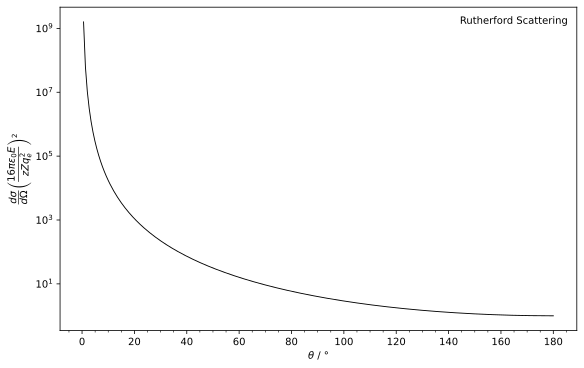

In [2]:
### Plot

ang = np.linspace(1e-2, np.pi, 250)

cs = 1 / np.sin(ang / 2)**4

plt.plot(ang * 180 / np.pi, cs, 'k-', lw=0.9)
plt.plot([], [], ' ', label='Rutherford Scattering')

plt.xticks(np.linspace(0, 180, 10))

plt.yscale('log')

plt.xlabel(r'$\theta$ / °')
plt.ylabel(r'$\dfrac{d\sigma}{d\Omega} \left( \dfrac{16\pi\varepsilon_0 E}{z Z q_e^2} \right)^2$')

plt.legend()

plt.savefig('plots/homework0.pdf')
plt.show()
plt.close()

### 1) Electron Plasma Regimes

**Relevant Proportionalities**

- Debye Length:

$$\lambda_D = \sqrt{\frac{\varepsilon_0 k_B T_e}{q_e^2 n_e}} \propto T_e^{1/2} n_e^{-1/2}$$

- Debye Number:

$$N_D = \tfrac{4}{3} \pi \lambda_D^3 n_e = \sqrt{\frac{16 \pi^2 \varepsilon_0^3 k_B^3 T_e^3}{9 q_e^6 n_e}} \propto T_e^{3/2} n_e^{-1/2}$$

- Fermi Temperature:

$$ \Theta_F = \frac{T_F}{T_e} = \frac{E_F}{k_B T_e} = \frac{\hbar^2}{2k_B m_e T_e} \sqrt[\scriptstyle 3 \,]{9\pi^4 n_e^2} \propto T_e^{-1} n_e^{2/3}$$

- Plasma Freqency:

$$ \omega_{pe} = \sqrt{\frac{q_e^2 n_e}{\varepsilon_0 m_e}} \propto n_e^{1/2}$$

**Typical Numerical Values**

|                          | $n_e \text{ / m}^{-3}$ | $T_e \text{ / K}$ |
|--------------------------|------------------------|-------------------|
| Solar Nucleus               | $10^{32}$              | $1.5 \cdot 10^7$  |
| Solar Photosphere        | $6 \cdot 10^{19}$      | $6 \cdot 10^3$    |
| Solar Corona             | $10^{14}$              | $10^6$            |
| Solar Coronal Loop       | $10^{16}$              | $10^6$            |
| Solar Wind               | $10^7$                 | $10^5$            |
| Earth Ionosphere         | $10^{11}$              | $1.2 \cdot 10^3$  |
| Ionized Hydrogen Regions | $10^7$                 | $2.2 \cdot 10^3$  |
| Tokamak                  | $10^{20}$              | $10^8$            |

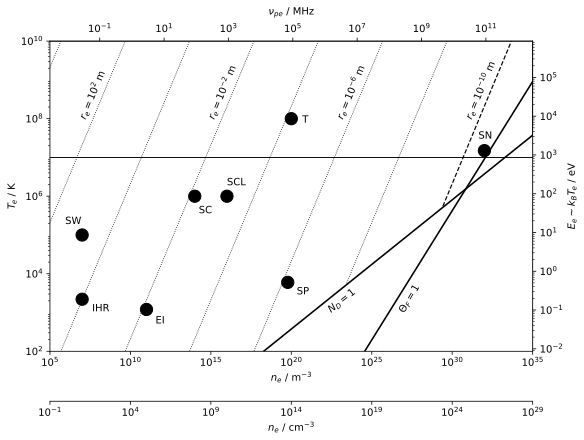

In [3]:
### Reproduction

qe = 1.60217663e-19
me = 9.1093837e-31
kB = 1.38064852e-23
hbar = 1.05457182e-34
eps0 = 8.8541878188e-12

def Te_isoradius(ne, lD):
    return lD**2 * qe**2 * ne / (eps0 * kB)

def Te_isocoupling(ne, nD):
    return (nD**2 * 9 * qe**6 * ne / (16 * np.pi**2 * eps0**3 * kB**3))**(1/3)

def Te_isodegeneracy(ne, thF):
    return hbar**2 * (3 * np.pi**2 * ne)**(2/3) / (2 * kB * me * thF)

fig, ax = plt.subplots(figsize=(8,6))

n = np.logspace(5, 35, 1000)

ax.plot(n, Te_isoradius(n, 1e-10), 'k--', lw=1.2, zorder=1)
ax.plot(n, Te_isoradius(n, 1e-8), 'k:', lw=0.8, zorder=1)
ax.plot(n, Te_isoradius(n, 1e-6), 'k:', lw=0.8, zorder=1)
ax.plot(n, Te_isoradius(n, 1e-4), 'k:', lw=0.8, zorder=1)
ax.plot(n, Te_isoradius(n, 1e-2), 'k:', lw=0.8, zorder=1)
ax.plot(n, Te_isoradius(n, 1e+0), 'k:', lw=0.8, zorder=1)
ax.plot(n, Te_isoradius(n, 1e+2), 'k:', lw=0.8, zorder=1)
ax.plot(n, Te_isoradius(n, 1e+4), 'k:', lw=0.8, zorder=1)
ax.plot(n, Te_isocoupling(n, 1), 'k-', lw=1.6, zorder=3)
ax.plot(n, Te_isodegeneracy(n, 1), 'k-', lw=1.6, zorder=3)

ax.fill_between(n, Te_isocoupling(n, 1), color='w', zorder=2)

ax.plot([1e4, 1e36], [1e7, 1e7], 'k-', lw=0.9, zorder=3)

x = [1e32, 6e19, 1e14, 1e16, 1e7, 1e11, 1e7, 1e20]
y = [1.5e7, 6e3, 1e6, 1e6, 1e5, 1.2e3, 2.2e3, 1e8]
labels = ['SN', 'SP', 'SC', 'SCL', 'SW', 'EI', 'IHR', 'T']
coords = [(-6, 12), (9, -12), (4, -17), (0, 11), (-17, 11), (9, -14), (10, -12), (11, -4)]
ax.scatter(x, y, color='k', marker='o', s=150)

for i in range(8):
    plt.annotate(labels[i], (x[i], y[i]), xytext=coords[i], textcoords='offset points')

plt.annotate(r'$r_e = 10^2 \text{ m}$', (5e6, 1e8), rotation=np.degrees(np.arctan(2.4)))
plt.annotate(r'$r_e = 10^{-2} \text{ m}$', (5e14, 1e8), rotation=np.degrees(np.arctan(2.4)))
plt.annotate(r'$r_e = 10^{-6} \text{ m}$', (5e22, 1e8), rotation=np.degrees(np.arctan(2.4)))
plt.annotate(r'$r_e = 10^{-10} \text{ m}$', (5e30, 1e8), rotation=np.degrees(np.arctan(2.4)))

plt.annotate(r'$N_D = 1$', (1.5e22, 1e3), rotation=np.degrees(np.arctan(0.8)))
plt.annotate(r'$\Theta_F = 1$', (4e26, 1e3), rotation=np.degrees(np.arctan(1.7)))

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(1e5, 1e35)
ax.set_ylim(1e2, 1e10)

ax.set_xticks(np.logspace(5, 35, 7))
ax.set_yticks(np.logspace(2, 10, 5))

ax.set_xlabel(r'$n_e$ / m$^{-3}$')
ax.set_ylabel(r'$T_{\! e}$ / K')

bottom = ax.secondary_xaxis('bottom', functions=(lambda x: x * 1e-6, lambda x: x * 1e+6))
bottom.set_xlabel(r'$n_e$ / cm$^{-3}$')
bottom.set_xticks(np.logspace(-1, 29, 7))
bottom.spines['bottom'].set_position(('outward', 50))

top = ax.secondary_xaxis('top', functions=(lambda x: np.sqrt(x * qe**2 / (eps0 * me)) * 1e-6 / (2 * np.pi), lambda x: eps0 * me * (x * 1e6 * 2 * np.pi)**2 / (qe**2)))
top.set_xlabel(r'$\nu_{pe}$ / MHz', labelpad=10)
top.set_xticks(np.logspace(-1, 11, 7))

side = ax.secondary_yaxis('right', functions=(lambda x: x * kB / qe, lambda x: x / kB * qe))
side.set_ylabel(r'$E_e \sim k_B T_{\! e}$ / eV')

plt.savefig('plots/homework1a.pdf')
plt.show()
plt.close()

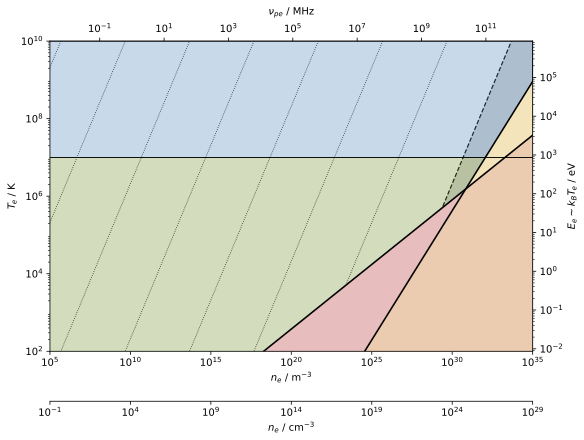

In [4]:
### Regions

fig, ax = plt.subplots(figsize=(8,6))

n = np.logspace(5, 35, 1000)

ax.plot(n, Te_isoradius(n, 1e-10), 'k--', lw=1.2, zorder=1)
ax.plot(n, Te_isoradius(n, 1e-8), 'k:', lw=0.8, zorder=1)
ax.plot(n, Te_isoradius(n, 1e-6), 'k:', lw=0.8, zorder=1)
ax.plot(n, Te_isoradius(n, 1e-4), 'k:', lw=0.8, zorder=1)
ax.plot(n, Te_isoradius(n, 1e-2), 'k:', lw=0.8, zorder=1)
ax.plot(n, Te_isoradius(n, 1e+0), 'k:', lw=0.8, zorder=1)
ax.plot(n, Te_isoradius(n, 1e+2), 'k:', lw=0.8, zorder=1)
ax.plot(n, Te_isoradius(n, 1e+4), 'k:', lw=0.8, zorder=1)
ax.plot(n, Te_isocoupling(n, 1), 'k-', lw=1.6, zorder=3)
ax.plot(n, Te_isodegeneracy(n, 1), 'k-', lw=1.6, zorder=3)

ax.fill_between(n, Te_isoradius(n, 1e-10), color='k', edgecolor='none', alpha=0.15, zorder=2)

ax.fill_between([1e4, 1e36], [1e7, 1e7], edgecolor='none', alpha=0.3, zorder=2)
ax.fill_between([1e4, 1e36], [1e7, 1e7], [1e10, 1e10], edgecolor='none', alpha=0.3, zorder=2)

ax.fill_between(n, Te_isocoupling(n, 1), color='w', edgecolor='none', zorder=2)
ax.fill_between(n, Te_isodegeneracy(n, 1), color='w', edgecolor='none', zorder=2)

ax.fill_between(n, Te_isocoupling(n, 1), edgecolor='none', alpha=0.3, zorder=2)
ax.fill_between(n, Te_isodegeneracy(n, 1), edgecolor='none', alpha=0.3, zorder=2)

ax.fill_between(n, np.minimum(Te_isocoupling(n, 1), Te_isodegeneracy(n, 1)), color='w', edgecolor='none', alpha=0.3, zorder=2)

ax.plot([1e4, 1e36], [1e7, 1e7], 'k-', lw=0.9, zorder=3)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(1e5, 1e35)
ax.set_ylim(1e2, 1e10)

ax.set_xticks(np.logspace(5, 35, 7))
ax.set_yticks(np.logspace(2, 10, 5))

ax.set_xlabel(r'$n_e$ / m$^{-3}$')
ax.set_ylabel(r'$T_{\! e}$ / K')

bottom = ax.secondary_xaxis('bottom', functions=(lambda x: x * 1e-6, lambda x: x * 1e+6))
bottom.set_xlabel(r'$n_e$ / cm$^{-3}$')
bottom.set_xticks(np.logspace(-1, 29, 7))
bottom.spines['bottom'].set_position(('outward', 50))

top = ax.secondary_xaxis('top', functions=(lambda x: np.sqrt(x * qe**2 / (eps0 * me)) * 1e-6 / (2 * np.pi), lambda x: eps0 * me * (x * 1e6 * 2 * np.pi)**2 / (qe**2)))
top.set_xlabel(r'$\nu_{pe}$ / MHz', labelpad=10)
top.set_xticks(np.logspace(-1, 11, 7))

side = ax.secondary_yaxis('right', functions=(lambda x: x * kB / qe, lambda x: x / kB * qe))
side.set_ylabel(r'$E_e \sim k_B T_{\! e}$ / eV')

plt.savefig('plots/homework1b.pdf')
plt.show()
plt.close()

**Legend**
- **Green:** Classical Weak Coupling (Nearly Ideal Gas)
- **Blue:** Relativistic Weak Coupling (Nearly Ideal Gas)
- **Shaded:** Quantum Effects (Atomic Radius Scale)
- **Yellow:** Quantum Effects (Degeneracy Dominated)
- **Red:** Strong Coupling (Thermal Energy Negligible)
- **Orange:** Strong Coupling & Quantum Effects (Overlap)

### 2) Saha Ionization Parameter

**Calculation Steps**

- Definition:

$$\alpha \equiv \frac{n_{H_\text{II}}}{n_{H_{I}} + n_{H_\text{II}}}$$

- Computation:

$$\begin{align*}
\frac{\alpha^2}{1 - \alpha^2} &= \frac{k_B T_e}{P_e} \left( \frac{2\pi m_e k_B T_e}{h^2} \right)^{3/2} e^{-E_ / k_B T_e} = \frac{1}{(1 + \alpha) n_e} \left( \frac{2\pi m_e k_B T_e}{h^2} \right)^{3/2} e^{-E_i / k_B T_e} \\
\frac{\alpha^2}{1 - \alpha} &= \frac{1}{n_e} \left( \frac{2\pi m_e k_B T_e}{h^2} \right)^{3/2} e^{-E_i / k_B T_e} \equiv f
\end{align*}$$

- Solution:

$$\alpha^2 + f \alpha - f = (\alpha + f/2)^2  - f^2/4 - f = 0$$

- Implementation:

$$\alpha = \sqrt{f^2 / 4 + f} - f/2 = \frac{\sqrt{f^2 + 4f} - f}{2} = \frac{\left(\sqrt{f^2 + 4f} - f\right)\left(\sqrt{f^2 + 4f} + f\right)}{2\left(\sqrt{f^2 + 4f} + f\right)} = \frac{2f}{\sqrt{f^2 + 4f} + f}$$

In [5]:
### Ionization

qe = 1.60217663e-19
me = 9.1093837e-31
kB = 1.38064852e-23
h = 6.62607016e-34
Ei = 2.17871e-18

def alpha(ne, Te):
    f = 1 / ne * (2 * np.pi * me * kB * Te / h**2)**(3/2) * np.exp(-Ei / (kB * Te))
    return 2 * f / (np.sqrt(f**2 + 4 * f) + f)

print(f'       Solar Core: α = {alpha(1e32, 1.5e7):.2f} ≠ 1.00')
print(f'Solar Photosphere: α = {alpha(6e19, 6e3):.2f}')
print(f'     Solar Corona: α = {alpha(1e14, 1e6):.2f}')

       Solar Core: α = 0.67 ≠ 1.00
Solar Photosphere: α = 0.01
     Solar Corona: α = 1.00


### 3)